# 01 · Outcomes & Statistics (Exp3) — *did it work / which is better?*

QC → selection toggle → outcomes (bars/ranks/subscales) → trajectories → statistics (familiar **+**
persona-paired) + comparisons. Key figures/tables are exported to `results/`. (Mechanism → `02`;
preference latent space → `03`; canonical thesis artifacts → `00`.)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, figures
figures.set_style()
ARMS   = exp3.discover_arms()
SCORES = exp3.load_scores_long(ARMS)
PALETTE = figures.arm_palette(sorted(SCORES.arm.unique()))
METRICS = [m for m in exp3.QUESTIONNAIRE_ORDER if m in SCORES.questionnaire.unique()]
ORACLE_NOISE = 0.10   # oracle reproducibility band (~0.07-0.10 |Δ|, partial-conv EDA): min meaningful diff
print("arms on disk:", [(a.label, len(a.iters)) for a in ARMS])
print("scores_long:", SCORES.shape, "| arms scored:", sorted(SCORES.arm.unique()))
print("exports ->", exp3.RESULTS_DIR)

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 2), ('GRPO_LA0', 4), ('GRPO_LA5', 2)]
scores_long: (12096, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 0 · Quality control

In [2]:
for a in ARMS:
    exp3.validate_recovery(a.conv_dir, a.seed, a.iters)
cov = SCORES.groupby(["arm","iteration","questionnaire"]).size()
print("eval coverage per cell — min:", cov.min(), "max:", cov.max())
display(training.scan_degeneracy(training.load_generations(ARMS))[
    ["arm","train_iter","n_candidates","pct_leak","pct_empty","pct_floored","mean_score"]])

persona recovery: permutation OK for iters [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]; age-in-intro match 102/102 (100%)
persona recovery: permutation OK for iters [0, 1]; age-in-intro match 18/18 (100%)
persona recovery: permutation OK for iters [0, 1, 2, 3]; age-in-intro match 33/33 (100%)
persona recovery: permutation OK for iters [0, 1]; age-in-intro match 19/19 (100%)
eval coverage per cell — min: 96 max: 96


,arm,train_iter,n_candidates,pct_leak,pct_empty,pct_floored,mean_score
0,GRPO_LA0,1,14352,0.0,0.18,0.18,3.074450
1,GRPO_LA0,2,6160,0.0,0.03,0.03,3.043861
2,GRPO_LA0,3,16032,0.0,0.01,0.01,3.252195
3,GRPO_LA5,1,7160,0.0,0.21,0.21,2.813640
4,PTO_LA0,1,7592,0.0,0.24,0.00,3.290739
5,PTO_LA0,2,6176,0.0,0.13,0.00,3.332432
6,PTO_LA0,3,6296,0.0,0.30,0.00,3.536591
7,PTO_LA0,4,5176,0.0,0.15,0.00,3.663854
8,PTO_LA0,5,4800,0.0,0.17,0.00,3.743945
9,PTO_LA0,6,4728,0.0,0.21,0.00,3.776678


## 1 · Selection toggle

In [3]:
SELECTION = "all"          # "all" | "best_per_exp"
if SELECTION == "best_per_exp":
    SEL, best = exp3.best_per_experiment(SCORES); display(best)
else:
    SEL = exp3.all_models(SCORES); print("Showing ALL models.")
SEL_ORDER = figures.model_order(SEL); print("models in view:", SEL.model.nunique())

Showing ALL models.
models in view: 18


## 2 · Familiar outcome comparison — bars, rankings, subscales

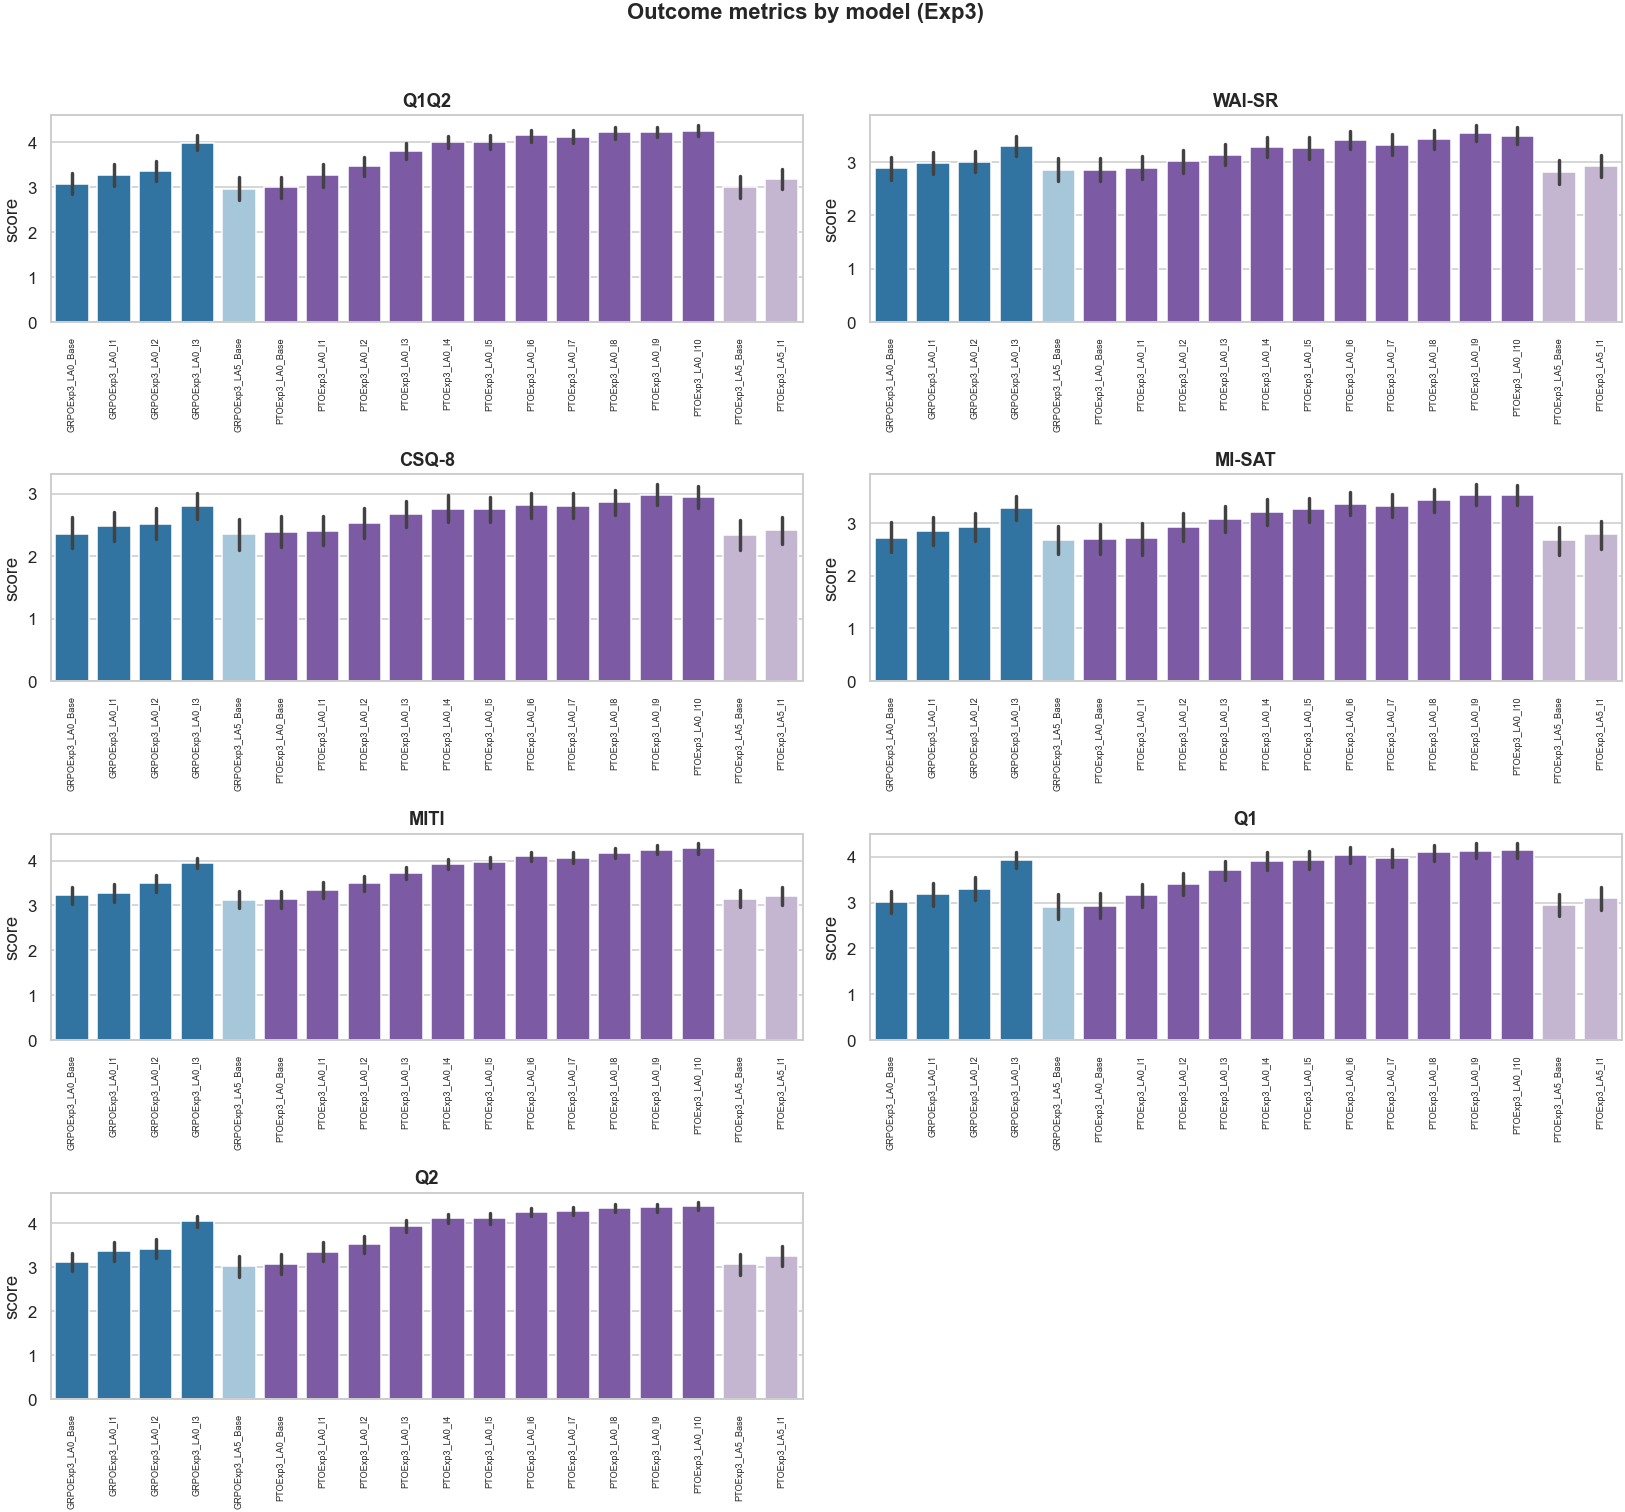

,arm,iteration,is_base,Q1Q2,WAI-SR,CSQ-8,MI-SAT,MITI,Q1,Q2,rank_Q1Q2,rank_WAI-SR,rank_CSQ-8,rank_MI-SAT,rank_MITI,rank_Q1,rank_Q2,AvgRank
model,,,,,,,,,,,,,,,,,,
PTOExp3_LA0_I10,PTO_LA0,10,False,4.260,3.497,2.945,3.536,4.273,4.140,4.380,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.429
PTOExp3_LA0_I9,PTO_LA0,9,False,4.238,3.536,2.980,3.540,4.242,4.121,4.356,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.571
PTOExp3_LA0_I8,PTO_LA0,8,False,4.221,3.424,2.865,3.429,4.172,4.100,4.341,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.000
PTOExp3_LA0_I6,PTO_LA0,6,False,4.154,3.406,2.816,3.368,4.091,4.044,4.264,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.143
PTOExp3_LA0_I7,PTO_LA0,7,False,4.129,3.326,2.801,3.328,4.068,3.975,4.283,5.0,5.0,6.0,5.0,5.0,5.0,4.0,5.000
GRPOExp3_LA0_I3,GRPO_LA0,3,False,3.993,3.301,2.811,3.290,3.938,3.935,4.051,8.0,6.0,5.0,6.0,7.0,6.0,8.0,6.571
PTOExp3_LA0_I5,PTO_LA0,5,False,4.014,3.264,2.749,3.262,3.961,3.923,4.106,6.0,8.0,8.0,7.0,6.0,7.0,7.0,7.000
PTOExp3_LA0_I4,PTO_LA0,4,False,4.008,3.280,2.751,3.210,3.924,3.900,4.115,7.0,7.0,7.0,8.0,8.0,8.0,6.0,7.286
PTOExp3_LA0_I3,PTO_LA0,3,False,3.815,3.140,2.676,3.078,3.719,3.702,3.928,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.000


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

In [4]:
fig, axes = figures.grid(len(METRICS), ncols=2, panel=(7.6, 3.4))
for ax, m in zip(axes, METRICS):
    sns.barplot(SEL[SEL.questionnaire==m], x="model", y="score", hue="arm", order=SEL_ORDER,
                palette=PALETTE, errorbar=("ci",95), dodge=False, ax=ax)
    ax.set_title(m); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=6)
    if ax.get_legend(): ax.legend_.remove()
fig.suptitle("Outcome metrics by model (Exp3)", y=1.02, fontweight="bold"); fig.tight_layout()
exp3.save_fig(fig, "outcomes_by_model", caption="All models, 6 rubrics; mean +/- 95% CI over 96 personas."); plt.show()
RANK = stats.rank_table(SEL).round(3); display(RANK)
exp3.save_table(RANK.reset_index(), "model_rankings", caption="Per-rubric rank (1=best) + average rank per model.")

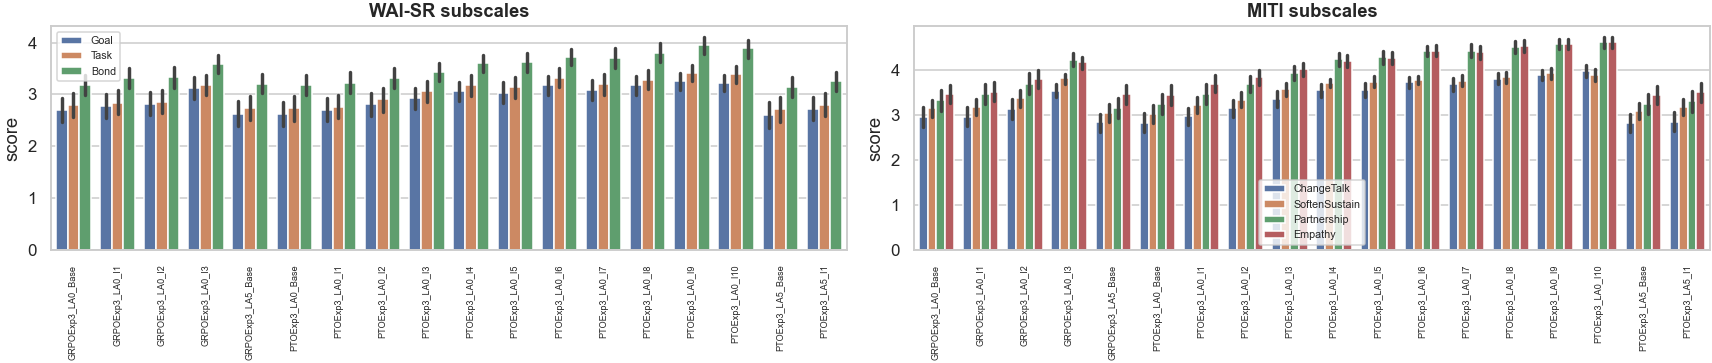

In [5]:
SUB = exp3.load_subscales(ARMS); SUB = SUB[SUB.model.isin(SEL.model.unique())]
fig, axes = figures.grid(2, ncols=2, panel=(8, 3.6))
for ax, parent in zip(axes, ["WAI-SR","MITI"]):
    d = SUB[SUB.parent==parent]; order=[m for m in SEL_ORDER if m in set(d.model)]
    sns.barplot(d, x="model", y="score", hue="subscale", order=order, errorbar=("ci",95), ax=ax)
    ax.set_title(f"{parent} subscales"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=6); ax.legend(fontsize=7, title="")
fig.tight_layout(); exp3.save_fig(fig, "subscales_WAI_MITI", caption="WAI-SR (Goal/Task/Bond) + MITI global subscales by model; mean +/- 95% CI."); plt.show()

## 3 · Per-iteration trajectories

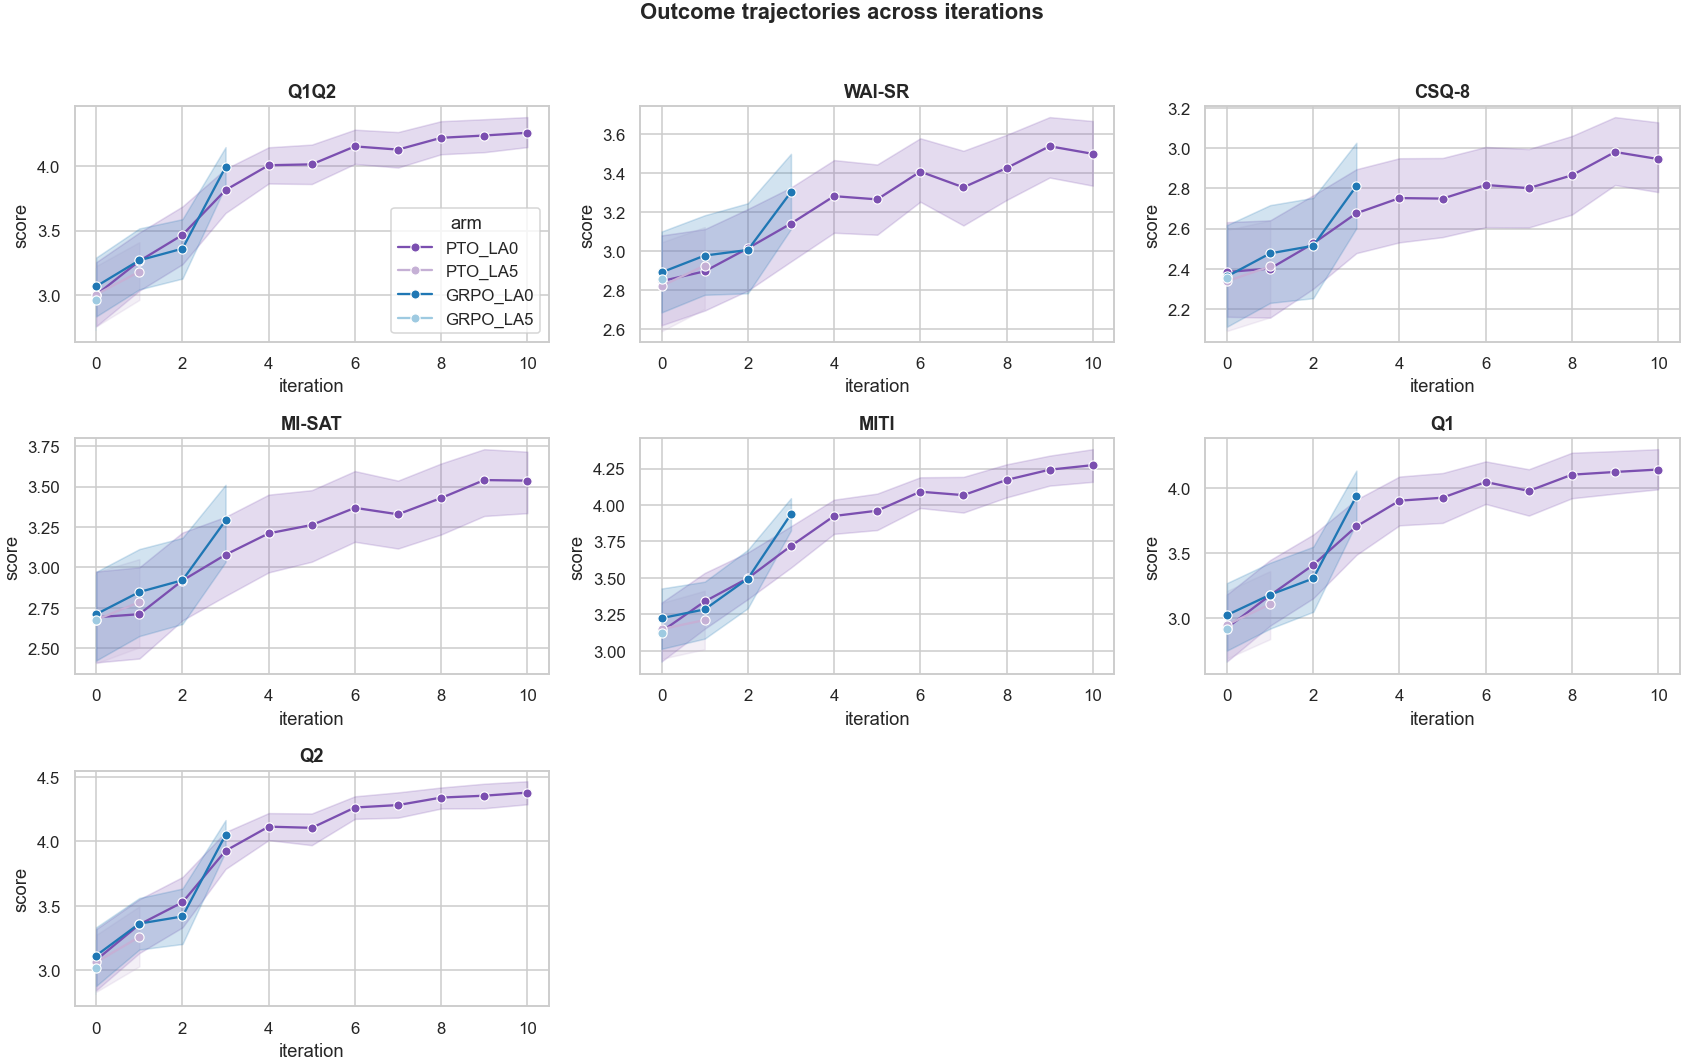

In [6]:
fig, axes = figures.grid(len(METRICS), ncols=3, panel=(5.2, 3.2))
for ax, m in zip(axes, METRICS):
    sns.lineplot(SCORES[SCORES.questionnaire==m], x="iteration", y="score", hue="arm",
                 palette=PALETTE, marker="o", errorbar=("ci",95), ax=ax); ax.set_title(m)
    if ax is not axes[0] and ax.get_legend(): ax.legend_.remove()
fig.suptitle("Outcome trajectories across iterations", y=1.02, fontweight="bold"); fig.tight_layout()
exp3.save_fig(fig, "trajectories_all_rubrics", caption="Per-rubric mean +/- 95% CI across iterations, arms overlaid."); plt.show()

## 4 · Statistics — familiar, persona-paired & repeated-measures

In [7]:
ARM = "PTO_LA0"
print(f"### Friedman repeated-measures omnibus — {ARM}")
FR = pd.DataFrame([stats.friedman_trajectory(SCORES, ARM, m) for m in METRICS]); display(FR.round(4))
print(f"### Familiar: Mann-Whitney vs base (+FDR) — {ARM}, Q1Q2"); display(stats.mannwhitney_vs_base(SCORES, ARM, "Q1Q2")[["iteration","n_iter","median_delta","cliffs_delta","U","p","p_fdr"]].round(4))
print(f"### Persona-paired: Wilcoxon + dz + bootstrap CI — {ARM}, Q1Q2")
PV = stats.paired_vs_base(SCORES, ARM, "Q1Q2")[["iteration","n","mean_delta","dz","p","p_holm","ci_low","ci_high"]].round(4); display(PV)
exp3.save_table(PV, "PTO_LA0_Q1Q2_vs_base_paired", caption="PTO_LA0 each iteration vs base on Q1+Q2; persona-paired Wilcoxon, dz, Holm p, bootstrap 95% CI.")

### Friedman repeated-measures omnibus — PTO_LA0


,arm,metric,chi2,p,kendall_w,k_iters,n_personas
0,PTO_LA0,Q1Q2,432.4498,0.0,0.4505,11,96
1,PTO_LA0,WAI-SR,254.6956,0.0,0.2653,11,96
2,PTO_LA0,CSQ-8,153.8643,0.0,0.1603,11,96
3,PTO_LA0,MI-SAT,191.6901,0.0,0.1997,11,96
4,PTO_LA0,MITI,400.5010,0.0,0.4172,11,96
5,PTO_LA0,Q1,359.2287,0.0,0.3742,11,96
6,PTO_LA0,Q2,455.1016,0.0,0.4741,11,96


### Familiar: Mann-Whitney vs base (+FDR) — PTO_LA0, Q1Q2


,iteration,n_iter,median_delta,cliffs_delta,U,p,p_fdr
0,1,96,0.3765,0.1264,5190.5,0.1305,0.1305
1,2,96,0.5765,0.2271,5654.5,0.0066,0.0073
2,3,96,1.0559,0.3746,6334.0,0.0000,0.0000
3,4,96,1.1206,0.4710,6778.5,0.0000,0.0000
4,5,96,1.2559,0.4676,6762.5,0.0000,0.0000
5,6,96,1.2853,0.5277,7039.5,0.0000,0.0000
6,7,96,1.1853,0.5279,7040.5,0.0000,0.0000
7,8,96,1.2853,0.5603,7190.0,0.0000,0.0000
8,9,96,1.3853,0.5789,7275.5,0.0000,0.0000
9,10,96,1.3147,0.5859,7308.0,0.0000,0.0000


### Persona-paired: Wilcoxon + dz + bootstrap CI — PTO_LA0, Q1Q2


,iteration,n,mean_delta,dz,p,p_holm,ci_low,ci_high
0,1,96,0.2632,0.2690,0.0352,0.0352,0.0814,0.4545
1,2,96,0.4659,0.4587,0.0000,0.0000,0.2651,0.6732
2,3,96,0.8145,0.8427,0.0000,0.0000,0.6185,1.0041
3,4,96,1.0072,1.0782,0.0000,0.0000,0.8208,1.1967
4,5,96,1.0141,1.0532,0.0000,0.0000,0.8221,1.2057
5,6,96,1.1536,1.2035,0.0000,0.0000,0.9693,1.3494
6,7,96,1.1287,1.1216,0.0000,0.0000,0.9314,1.3231
7,8,96,1.2203,1.2504,0.0000,0.0000,1.0300,1.4240
8,9,96,1.2381,1.3100,0.0000,0.0000,1.0483,1.4242
9,10,96,1.2594,1.4288,0.0000,0.0000,1.0859,1.4336


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

### Controlled comparisons (paired; skips absent arms)

In [8]:
def common_iters(a,b): return sorted(set(SCORES[SCORES.arm==a].iteration) & set(SCORES[SCORES.arm==b].iteration))
def model_at(a,it):
    s=SCORES[(SCORES.arm==a)&(SCORES.iteration==it)]; return s.model.iloc[0] if len(s) else None
out=[]
for it in common_iters("PTO_LA0","GRPO_LA0"):
    ma,mb=model_at("PTO_LA0",it),model_at("GRPO_LA0",it)
    if ma and mb: out.append(stats.compare_two_models(SCORES,ma,mb).assign(iteration=it))
if out:
    CMP=pd.concat(out)[["iteration","metric","n","mean_delta","dz","p","p_holm"]].round(4)
    print("PTO_LA0 - GRPO_LA0 (paired; + => PTO higher):"); display(CMP)
    exp3.save_table(CMP, "PTO_vs_GRPO_LA0_paired", caption="PTO_LA0 - GRPO_LA0 at matched iterations; persona-paired Wilcoxon + dz + Holm.")
else: print("No common PTO/GRPO scored iterations yet.")
for method in ["PTO","GRPO"]:
    a0,a5=f"{method}_LA0",f"{method}_LA5"; ci=common_iters(a0,a5) if a5 in set(SCORES.arm) else []
    if ci:
        o=[stats.compare_two_models(SCORES,model_at(a0,it),model_at(a5,it)).assign(iteration=it) for it in ci]
        print(f"{a0} - {a5} (K0 - K5):"); display(pd.concat(o)[["iteration","metric","mean_delta","dz","p_holm"]].round(4))
    else: print(f"{a5}: not scored yet — K0-vs-K5 for {method} pending.")

PTO_LA0 - GRPO_LA0 (paired; + => PTO higher):


,iteration,metric,n,mean_delta,dz,p,p_holm
0,0,Q1Q2,96,-0.0664,-0.0688,0.8416,1.0000
1,0,WAI-SR,96,-0.0451,-0.0675,0.6093,1.0000
2,0,CSQ-8,96,0.0221,0.0316,0.7990,1.0000
3,0,MI-SAT,96,-0.0191,-0.0213,0.9270,1.0000
4,0,MITI,96,-0.0911,-0.1021,0.8387,1.0000
5,0,Q1,96,-0.0979,-0.0976,0.4368,1.0000
6,0,Q2,96,-0.0349,-0.0354,0.5560,1.0000
0,1,Q1Q2,96,-0.0055,-0.0060,0.5500,1.0000
1,1,WAI-SR,96,-0.0807,-0.1129,0.3555,1.0000
2,1,CSQ-8,96,-0.0755,-0.1153,0.3195,1.0000


PTO_LA0 - PTO_LA5 (K0 - K5):


,iteration,metric,mean_delta,dz,p_holm
0,0,Q1Q2,-0.0029,-0.0028,1.0000
1,0,WAI-SR,0.0252,0.0353,1.0000
2,0,CSQ-8,0.0456,0.0676,1.0000
3,0,MI-SAT,0.0156,0.0192,1.0000
4,0,MITI,-0.0156,-0.0172,1.0000
5,0,Q1,-0.0229,-0.0217,1.0000
6,0,Q2,0.0172,0.0155,1.0000
0,1,Q1Q2,0.0828,0.0931,1.0000
1,1,WAI-SR,-0.0295,-0.0452,1.0000
2,1,CSQ-8,-0.0104,-0.0150,1.0000


GRPO_LA0 - GRPO_LA5 (K0 - K5):


,iteration,metric,mean_delta,dz,p_holm
0,0,Q1Q2,0.1036,0.1148,1.0
1,0,WAI-SR,0.0330,0.0509,1.0
2,0,CSQ-8,0.0065,0.0112,1.0
3,0,MI-SAT,0.0365,0.0444,1.0
4,0,MITI,0.1042,0.1280,1.0
5,0,Q1,0.1104,0.1196,1.0
6,0,Q2,0.0968,0.1032,1.0


## 5 · Robustness — selection sensitivity
Does the main-results conclusion hold under `all` vs `best_per_exp`? (the table targets differ: final vs best iteration).

In [9]:
mr_final = stats.main_results_table(SCORES, target="final")
mr_best  = stats.main_results_table(SCORES, target="best")
print("target=FINAL iteration:"); display(mr_final[mr_final.arm=="PTO_LA0"][["rubric","target_iter","delta","dz","effect","p_holm"]])
print("target=BEST iteration (by own oracle):"); display(mr_best[mr_best.arm=="PTO_LA0"][["rubric","target_iter","delta","dz","effect","p_holm"]])
print(">> conclusions stable if effect sizes stay large & p_holm significant under both targets.")

target=FINAL iteration:


,rubric,target_iter,delta,dz,effect,p_holm
7,Q1Q2,10,1.259,1.429,large,0.0
8,WAI-SR,10,0.653,0.968,large,0.0
9,CSQ-8,10,0.561,0.805,large,0.0
10,MI-SAT,10,0.845,0.954,large,0.0
11,MITI,10,1.141,1.347,large,0.0
12,Q1,10,1.217,1.389,large,0.0
13,Q2,10,1.302,1.384,large,0.0


target=BEST iteration (by own oracle):


,rubric,target_iter,delta,dz,effect,p_holm
7,Q1Q2,10,1.259,1.429,large,0.0
8,WAI-SR,10,0.653,0.968,large,0.0
9,CSQ-8,10,0.561,0.805,large,0.0
10,MI-SAT,10,0.845,0.954,large,0.0
11,MITI,10,1.141,1.347,large,0.0
12,Q1,10,1.217,1.389,large,0.0
13,Q2,10,1.302,1.384,large,0.0


>> conclusions stable if effect sizes stay large & p_holm significant under both targets.


## 6 · Takeaways
- _(which arm/K wins; where it plateaus; robustness)_